In [27]:
from zedstat import zedstat

import pandas as pd
data_path = './PROBLEMATIC_NAN_LR_M5075PTSD.parquet'
deployment_prevalence = 0.05
df = pd.read_parquet(data_path)

rf, total_samples, positive_samples = zedstat.genroc(
    df,
    risk="predicted_risk",
    target="target",
)

zt = zedstat.processRoc(
    rf,
    prevalence=deployment_prevalence,
    total_samples=total_samples,
    positive_samples=positive_samples,
    alpha=0.05,
    lr_fpr_floor=0.001,
)
zt.smooth(STEP=0.01, convexify=False)
zt.allmeasures(interpolate=True)
zt.usample(precision=3, recompute_measures=True)
zt.getBounds(
    ppv_ci_method="direct",
    min_expected_flags=10.0,
    min_expected_fp=5.0,
    min_expected_tn=5.0,
    enforce_bounds=True,
    smooth_ppv_bounds=True,
    mask_dominated_lr=True,
    lr_min_plus=1.001,
)

perf_df =  zt.get(0)
    

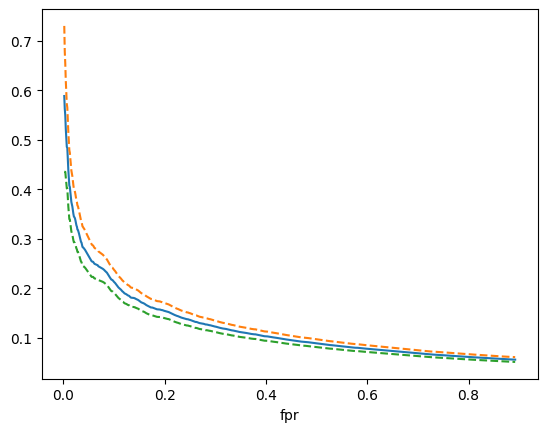

In [28]:
ax=perf_df.dropna().ppv.plot()
ax=perf_df.dropna().ppv_upper.plot(style='--')
ax=perf_df.dropna().ppv_lower.plot(style='--')


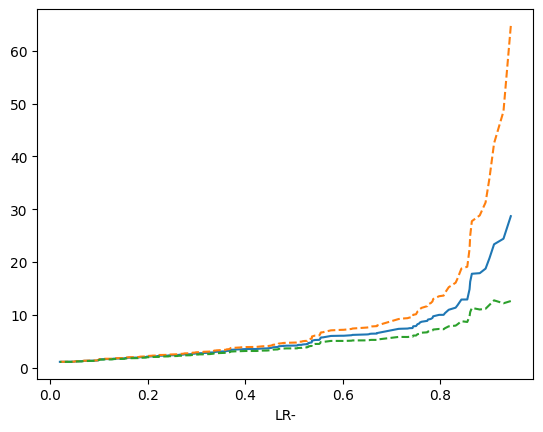

In [29]:
ax=perf_df.set_index('LR-').dropna()['LR+'].plot()
ax=perf_df.set_index('LR-').dropna()['LR+_upper'].plot(style='--')
ax=perf_df.set_index('LR-').dropna()['LR+_lower'].plot(style='--')


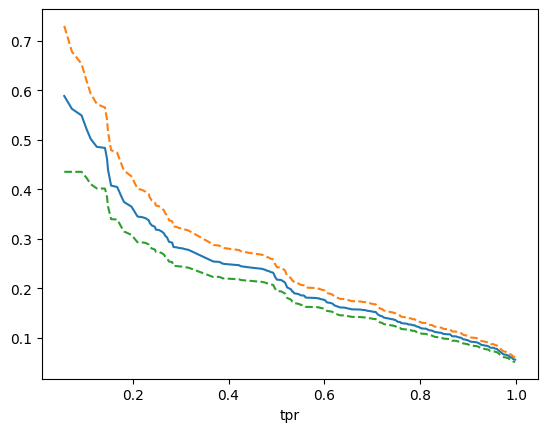

In [30]:
ax=perf_df.set_index('tpr').dropna().ppv.plot()
ax=perf_df.set_index('tpr').dropna().ppv_upper.plot(style='--')
ax=perf_df.set_index('tpr').dropna().ppv_lower.plot(style='--')


In [32]:
perf_df.interpolate().head(52)

,tpr,ppv,acc,npv,LR+,LR-,threshold,expected_fp,expected_tn,expected_flags,...,tpr_lower,ppv_lower,acc_lower,npv_lower,LR+_lower,LR-_lower,threshold_lower,expected_fp_lower,expected_tn_lower,expected_flags_lower
fpr,,,,,,,,,,,,,,,,,,,,,
0.000,0.000000,0.803823,0.950000,0.950000,NaN,NaN,0.136154,0.000,9167.000,0.000000,...,0.000000,0.435090,0.949602,0.949980,NaN,NaN,0.136154,0.000,9167.000,0.000000
0.001,0.015926,0.588298,0.949846,0.950710,NaN,NaN,0.123381,9.167,9157.833,16.830690,...,0.007945,0.435090,0.948603,0.950288,NaN,NaN,0.123381,9.167,9157.833,16.830690
0.002,0.057325,0.588298,0.950966,0.952641,28.681063,0.944564,0.103094,18.334,9148.666,45.937041,...,0.039693,0.435090,0.948996,0.951745,12.620318,0.919049,0.103094,18.334,9148.666,45.937041
0.003,0.073251,0.562396,0.950813,0.953359,24.418482,0.929538,0.095405,27.501,9139.499,62.767731,...,0.053016,0.435090,0.948521,0.952328,12.196586,0.901476,0.095405,27.501,9139.499,62.767731
0.004,0.093418,0.549047,0.950871,0.954284,23.358453,0.910223,0.088694,36.668,9130.332,81.642659,...,0.070326,0.435090,0.948276,0.953106,12.750625,0.879461,0.088694,36.668,9130.332,81.642659
0.005,0.103684,0.521854,0.950434,0.954735,20.736815,0.900820,0.086753,45.835,9121.165,95.745652,...,0.079284,0.423016,0.947632,0.953485,11.894098,0.868761,0.086753,45.835,9121.165,95.745652
0.006,0.112539,0.501471,0.949927,0.955119,18.756521,0.892818,0.083488,55.002,9111.998,109.169278,...,0.087077,0.410063,0.946943,0.953810,11.162244,0.859695,0.083488,55.002,9111.998,109.169278
0.007,0.125265,0.485529,0.949613,0.955691,17.895660,0.880901,0.080731,64.169,9102.831,124.458093,...,0.098370,0.401515,0.946439,0.954306,11.021738,0.846421,0.080731,64.169,9102.831,124.458093
0.008,0.142251,0.483439,0.949513,0.956472,17.782051,0.864667,0.075851,73.336,9093.664,141.799331,...,0.113594,0.401246,0.946141,0.954995,11.313414,0.828583,0.075851,73.336,9093.664,141.799331


In [23]:
import numpy as np
perf_df.loc[0.05,:]=np.nan


In [26]:
perf_df.head(52)

,tpr,ppv,acc,npv,LR+,LR-,threshold,expected_fp,expected_tn,expected_flags,...,tpr_lower,ppv_lower,acc_lower,npv_lower,LR+_lower,LR-_lower,threshold_lower,expected_fp_lower,expected_tn_lower,expected_flags_lower
fpr,,,,,,,,,,,,,,,,,,,,,
0.000,0.000000,0.803823,0.950000,0.950000,NaN,NaN,0.136154,0.000,9167.000,0.000000,...,0.000000,0.435090,0.949602,0.949980,NaN,NaN,0.136154,0.000,9167.000,0.000000
0.001,0.015926,0.588298,0.949846,0.950710,NaN,NaN,0.123381,9.167,9157.833,16.830690,...,0.007945,0.435090,0.948603,0.950288,NaN,NaN,0.123381,9.167,9157.833,16.830690
0.002,0.057325,0.588298,0.950966,0.952641,28.681063,0.944564,0.103094,18.334,9148.666,45.937041,...,0.039693,0.435090,0.948996,0.951745,12.620318,0.919049,0.103094,18.334,9148.666,45.937041
0.003,0.073251,0.562396,0.950813,0.953359,24.418482,0.929538,0.095405,27.501,9139.499,62.767731,...,0.053016,0.435090,0.948521,0.952328,12.196586,0.901476,0.095405,27.501,9139.499,62.767731
0.004,0.093418,0.549047,0.950871,0.954284,23.358453,0.910223,0.088694,36.668,9130.332,81.642659,...,0.070326,0.435090,0.948276,0.953106,12.750625,0.879461,0.088694,36.668,9130.332,81.642659
0.005,0.103684,0.521854,0.950434,0.954735,20.736815,0.900820,0.086753,45.835,9121.165,95.745652,...,0.079284,0.423016,0.947632,0.953485,11.894098,0.868761,0.086753,45.835,9121.165,95.745652
0.006,0.112539,0.501471,0.949927,0.955119,18.756521,0.892818,0.083488,55.002,9111.998,109.169278,...,0.087077,0.410063,0.946943,0.953810,11.162244,0.859695,0.083488,55.002,9111.998,109.169278
0.007,0.125265,0.485529,0.949613,0.955691,17.895660,0.880901,0.080731,64.169,9102.831,124.458093,...,0.098370,0.401515,0.946439,0.954306,11.021738,0.846421,0.080731,64.169,9102.831,124.458093
0.008,0.142251,0.483439,0.949513,0.956472,17.782051,0.864667,0.075851,73.336,9093.664,141.799331,...,0.113594,0.401246,0.946141,0.954995,11.313414,0.828583,0.075851,73.336,9093.664,141.799331
